# Phase 1 — Data Processing & EDA
### KDD Cup 1999 (10% subset) — Network Intrusion Detection

This notebook uses the helper functions in `data_preprocessing.py` to load and
clean the raw `kddcup.data_10_percent_corrected` file, explores it briefly,
then performs the Phase 1 feature-engineering steps:

1. Load raw data and clean it with `data_preprocessing.clean_data`
2. Exploratory Data Analysis (EDA)
3. One-Hot Encode categorical features (`protocol_type`, `service`, `flag`)
4. Standard-Scale all numerical features
5. Split into a **Training Set** (normal traffic only) and a **Testing Set**
   (mix of normal traffic + anomalies)
6. Save the processed splits to `data/processed/`


## 1. Setup & Imports

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 60)


In [7]:
# data_preprocessing.py lives alongside this notebook
import sys
from pathlib import Path

src_dir = Path("../src")
sys.path.append(str(src_dir.resolve()))

from data_preprocessing import load_data, clean_data

## 2. Locate & Load the Raw Data

The raw `kddcup.data_10_percent_corrected` file has **no header row**, so we
supply the standard 41 KDD Cup 1999 feature names plus the `label` column.

By default this notebook looks for the file at `data/raw/kddcup.data_10_percent_corrected`
relative to the notebook. If your file lives elsewhere, edit `DATA_PATH` below.


In [8]:
# Standard KDD Cup 1999 column names (41 features + label)
KDD_COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label",
]

CATEGORICAL_COLS = ["protocol_type", "service", "flag"]

# --- Locate the raw data file -------------------------------------------------
CANDIDATE_PATHS = [
    Path("data/raw/kddcup.data_10_percent_corrected"),
    Path("../data/raw/kddcup.data_10_percent_corrected"),
    Path("kddcup.data_10_percent_corrected"),
    Path("/mnt/user-data/uploads/kddcup.data_10_percent_corrected"),
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), CANDIDATE_PATHS[0])

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find 'kddcup.data_10_percent_corrected'. Checked: "
        f"{[str(p) for p in CANDIDATE_PATHS]}\n"
        "Place the file at 'data/raw/kddcup.data_10_percent_corrected' "
        "(relative to this notebook) and re-run, or update DATA_PATH manually."
    )

print(f"Loading data from: {DATA_PATH.resolve()}")
raw_df = load_data(DATA_PATH, header=None, names=KDD_COLUMNS)
print(f"Raw shape: {raw_df.shape}")
raw_df.head()


Loading data from: C:\Users\Emery\Documents\GitHub\SEP740-CourseProject-G9-P19-AnomalyDetection\data\raw\kddcup.data_10_percent_corrected
Raw shape: (494021, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


## 3. Clean the Data

We reuse `clean_data` from `data_preprocessing.py`, which:
- normalizes column names and whitespace
- standardizes missing-value markers to `NaN`
- drops duplicate rows
- drops columns with too much missing data
- imputes numeric columns (median) and categorical columns (most frequent)

We keep `encode_categorical=False` here because we'll do the encoding
ourselves (One-Hot instead of Ordinal) in the next steps.


In [9]:
df = clean_data(
    raw_df,
    drop_duplicates=True,
    missing_threshold=0.5,
    numeric_strategy="median",
    categorical_strategy="most_frequent",
    encode_categorical=False,
)

# KDD labels look like 'normal.', 'neptune.', 'smurf.', etc. -> strip trailing '.'
df["label"] = df["label"].astype(str).str.rstrip(".")

# Binary label used later for the train/test split
df["binary_label"] = np.where(df["label"] == "normal", "normal", "anomaly")

print(f"Cleaned shape: {df.shape}")
df.head()


Cleaned shape: (145586, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,binary_label
0,0.0,tcp,http,SF,181.0,5450.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9.0,9.0,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal,normal
1,0.0,tcp,http,SF,239.0,486.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19.0,19.0,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal,normal
2,0.0,tcp,http,SF,235.0,1337.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29.0,29.0,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal,normal
3,0.0,tcp,http,SF,219.0,1337.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39.0,39.0,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal,normal
4,0.0,tcp,http,SF,217.0,2032.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49.0,49.0,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal,normal


## 4. Exploratory Data Analysis (EDA)

In [10]:
df.info()


<class 'pandas.DataFrame'>
Index: 145586 entries, 0 to 494020
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     145586 non-null  float64
 1   protocol_type                145586 non-null  str    
 2   service                      145586 non-null  str    
 3   flag                         145586 non-null  str    
 4   src_bytes                    145586 non-null  float64
 5   dst_bytes                    145586 non-null  float64
 6   land                         145586 non-null  float64
 7   wrong_fragment               145586 non-null  float64
 8   urgent                       145586 non-null  float64
 9   hot                          145586 non-null  float64
 10  num_failed_logins            145586 non-null  float64
 11  logged_in                    145586 non-null  float64
 12  num_compromised              145586 non-null  float64
 13  root_shell     

In [11]:
df.describe()


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,145586.000000,1.455860e+05,1.455860e+05,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.0,145586.0,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000
mean,132.025181,7.995700e+03,2.859780e+03,0.000137,0.020201,0.000048,0.100174,0.000515,0.491490,0.026177,0.000378,0.000124,0.038520,0.003675,0.000371,0.003414,0.0,0.0,0.004705,74.385593,13.011464,0.291379,0.291551,0.108355,0.108412,0.655194,0.040576,0.093079,181.468177,129.934678,0.553222,0.061389,0.092825,0.019048,0.291597,0.290978,0.110463,0.107675
std,1224.157053,1.820383e+06,6.080979e+04,0.011720,0.239368,0.010150,1.426798,0.028585,0.499929,3.311373,0.019433,0.014354,3.707494,0.177581,0.020298,0.067091,0.0,0.0,0.068433,100.335945,30.736126,0.452903,0.453567,0.308961,0.308805,0.446795,0.120396,0.241952,99.098197,114.714829,0.456236,0.147021,0.241123,0.060410,0.452492,0.453447,0.306097,0.304220
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.080000,0.000000,0.000000,78.000000,12.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.470000e+02,1.050000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,117.000000,0.770000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.880000e+02,1.164750e+03,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,132.000000,15.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.030000,0.020000,1.000000,1.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,1.000000,2.000000,993.000000,28.000000,2.000000,8.000000,0.0,0.0,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


binary_label
normal     87832
anomaly    57754
Name: count, dtype: int64

binary_label
normal     0.603
anomaly    0.397
Name: proportion, dtype: float64


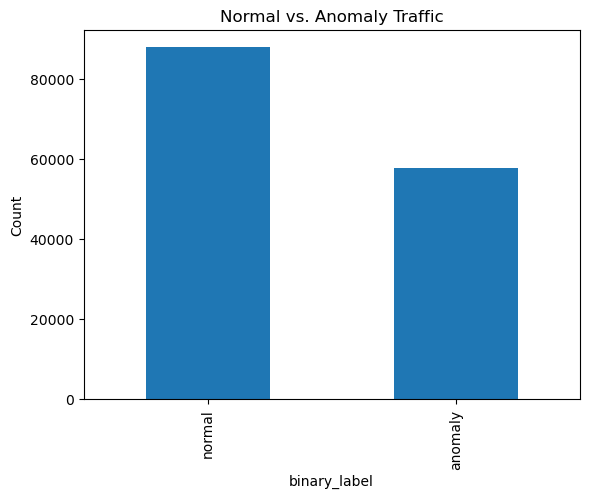

In [12]:
# Class balance: normal vs. anomaly
print(df["binary_label"].value_counts())
print()
print(df["binary_label"].value_counts(normalize=True).round(3))

df["binary_label"].value_counts().plot(kind="bar", title="Normal vs. Anomaly Traffic")
plt.ylabel("Count")
plt.show()


In [13]:
# Top attack types (within 'anomaly')
df.loc[df["binary_label"] == "anomaly", "label"].value_counts().head(15)


label
neptune            51820
back                 968
teardrop             918
satan                906
warezclient          893
ipsweep              651
smurf                641
portsweep            416
pod                  206
nmap                 158
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  19
imap                  12
Name: count, dtype: int64

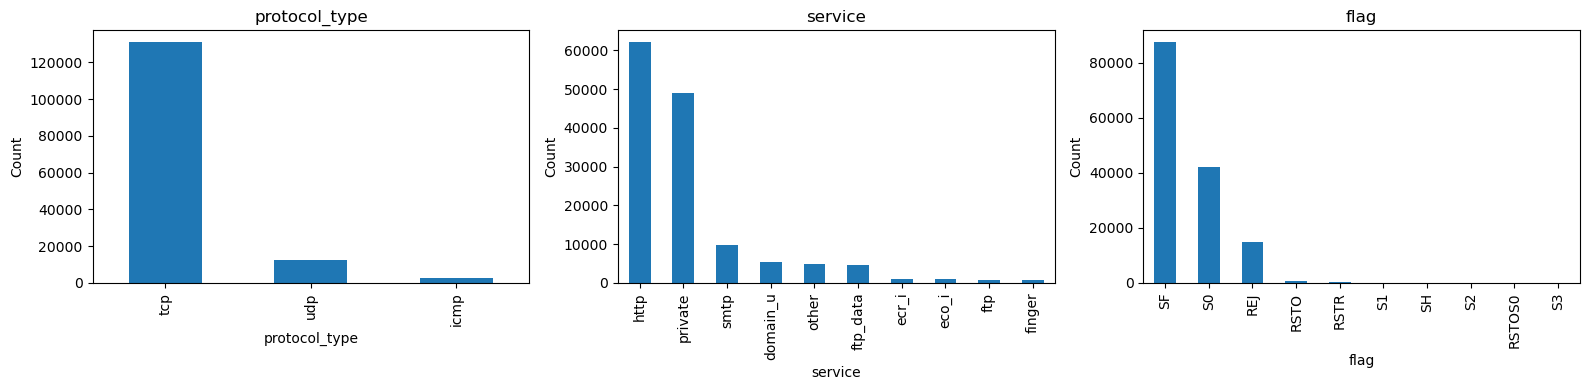

In [14]:
# Distribution of key categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["protocol_type", "service", "flag"]):
    top_vals = df[col].value_counts().head(10)
    top_vals.plot(kind="bar", ax=ax, title=col)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


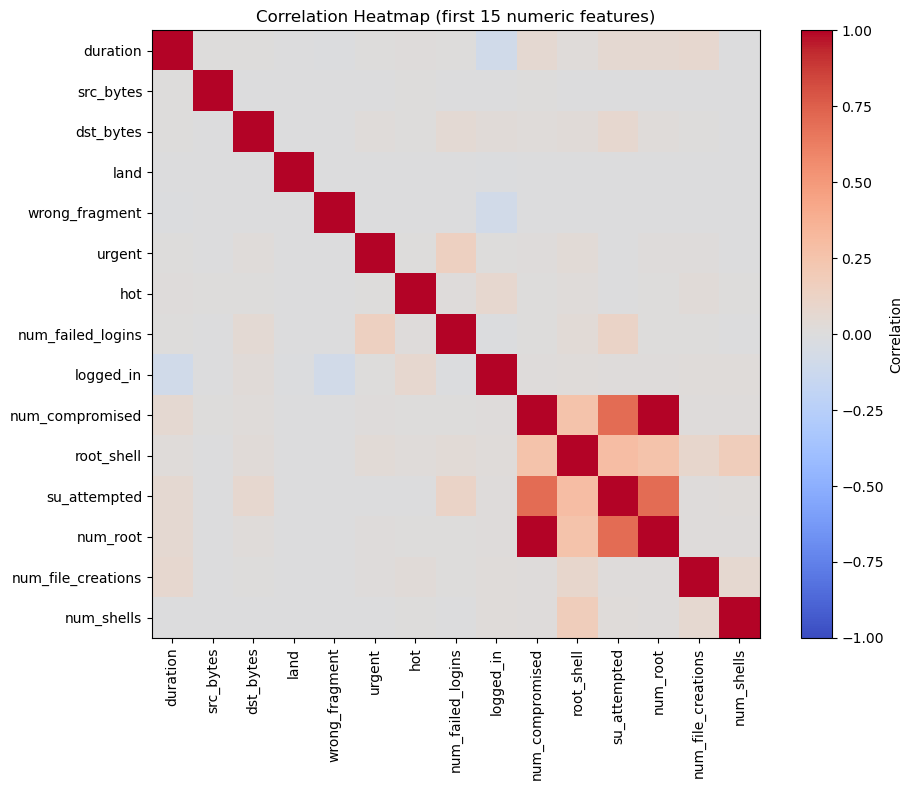

In [15]:
# Quick look at correlations among numeric features
numeric_preview_cols = df.select_dtypes(include=["number"]).columns[:15]
plt.figure(figsize=(10, 8))
plt.imshow(df[numeric_preview_cols].corr(), cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(numeric_preview_cols)), numeric_preview_cols, rotation=90)
plt.yticks(range(len(numeric_preview_cols)), numeric_preview_cols)
plt.colorbar(label="Correlation")
plt.title("Correlation Heatmap (first 15 numeric features)")
plt.tight_layout()
plt.show()


## 5. One-Hot Encode Categorical Features

Apply One-Hot Encoding to `protocol_type`, `service`, and `flag`.


In [16]:
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS, prefix=CATEGORICAL_COLS)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")
df_encoded.head()


Shape before encoding: (145586, 43)
Shape after encoding:  (145586, 120)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,...,service_remote_job,service_rje,service_shell,service_smtp,service_sql_net,service_ssh,service_sunrpc,service_supdup,service_systat,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.0,181.0,5450.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9.0,9.0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0.0,239.0,486.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19.0,19.0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,0.0,235.0,1337.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29.0,29.0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,0.0,219.0,1337.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39.0,39.0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,0.0,217.0,2032.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49.0,49.0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


## 6. Identify Numerical Features for Scaling

We scale every numeric feature *except* the labels. Since this is set up as
an anomaly-detection problem (train on normal traffic only), the scaler is
**fit on the training split only** and then applied to the test split, to
avoid leaking information about the anomalies into the scaling parameters.
This happens in the split step below.


In [17]:
exclude_cols = {"label", "binary_label"}
numeric_cols = [
    c for c in df_encoded.select_dtypes(include=["number"]).columns
    if c not in exclude_cols
]
print(f"Number of numeric feature columns to scale: {len(numeric_cols)}")
numeric_cols[:10]


Number of numeric feature columns to scale: 38


['duration',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised']

## 7. Split the Dataset

- **Training Set**: normal traffic only (a portion of all `normal` rows)
- **Testing Set**: the remaining normal traffic + all anomalies (a realistic
  mix for evaluating an anomaly/intrusion detector)


In [18]:
TEST_SIZE_NORMAL = 0.30  # fraction of normal traffic held out for testing
RANDOM_STATE = 42

normal_df = df_encoded[df_encoded["binary_label"] == "normal"].reset_index(drop=True)
anomaly_df = df_encoded[df_encoded["binary_label"] == "anomaly"].reset_index(drop=True)

train_normal, test_normal = train_test_split(
    normal_df, test_size=TEST_SIZE_NORMAL, random_state=RANDOM_STATE
)

train_df = train_normal.reset_index(drop=True)
test_df = (
    pd.concat([test_normal, anomaly_df], axis=0)
    .sample(frac=1, random_state=RANDOM_STATE)  # shuffle
    .reset_index(drop=True)
)

print(f"Training set (normal only): {train_df.shape}")
print(train_df['binary_label'].value_counts())
print()
print(f"Testing set (mixed):        {test_df.shape}")
print(test_df['binary_label'].value_counts())


Training set (normal only): (61482, 120)
binary_label
normal    61482
Name: count, dtype: int64

Testing set (mixed):        (84104, 120)
binary_label
anomaly    57754
normal     26350
Name: count, dtype: int64


## 8. Scale Numerical Features

Fit `StandardScaler` on the training set (normal traffic only) and apply the
same transformation to the test set.


In [19]:
scaler = StandardScaler()
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

train_df[numeric_cols].describe().loc[["mean", "std"]]


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
mean,-3.802228e-17,5.778461e-18,6.471877e-18,0.0,0.0,0.0,-1.017009e-17,4.853908e-18,-6.656788e-17,-2.311385e-18,6.934154e-18,2.773662e-18,-1.849108e-18,-1.201920e-17,-8.320985e-18,-3.467077e-17,0.0,0.0,2.403840e-17,1.617969e-18,4.125821e-17,6.703015e-18,-1.034345e-17,-1.044746e-16,-1.155692e-17,-5.554257e-16,-7.858708e-18,-1.849108e-18,7.858708e-18,1.678065e-16,1.893024e-16,1.386831e-17,2.126474e-17,-4.668997e-17,4.622769e-18,-1.201920e-17,8.783261e-18,3.513305e-17
std,1.000008e+00,1.000008e+00,1.000008e+00,0.0,0.0,0.0,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,0.0,0.0,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00


## 9. Save Processed Data

Save the final training and testing sets to `data/processed/`.


In [21]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

train_path = output_dir / "train.csv"
test_path = output_dir / "test.csv"

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Saved training set -> {train_path.resolve()}  {train_df.shape}")
print(f"Saved testing set  -> {test_path.resolve()}  {test_df.shape}")


Saved training set -> C:\Users\Emery\Documents\GitHub\SEP740-CourseProject-G9-P19-AnomalyDetection\data\processed\train.csv  (61482, 120)
Saved testing set  -> C:\Users\Emery\Documents\GitHub\SEP740-CourseProject-G9-P19-AnomalyDetection\data\processed\test.csv  (84104, 120)


## Summary

| Split | Contents | Rows | Purpose |
|---|---|---|---|
| `data/processed/train.csv` | Normal traffic only | see output above | Train a one-class / anomaly-detection model on 'normal' behavior |
| `data/processed/test.csv`  | Normal + anomalies | see output above | Evaluate the model's ability to flag anomalies |

Both files contain the same one-hot-encoded and scaled feature columns, plus
the original `label` (specific attack type) and `binary_label`
(`normal`/`anomaly`) columns for reference/evaluation.
